# Berka empirical baseline for the PRL paper

Pedagogical companion to `paper/Transactions/SUBMISSION_PRL.tex`. Structure follows the model's logical flow:

1. **Stage** — what the dataset looks like (balance trajectories).
2. **Inputs** — what the simulator needs to be told: spending propensity $h(s)$, within-account dispersion $\hat\xi$, activity/attractiveness degree marginals, and the copula linking them.
3. **Intermediate** — a conditional check on $P(m\mid s)$ binned by $s$, the SM's `conditional_distributions.pdf` figure made on Berka data.
4. **Outputs** — what the simulator's outputs should look like: $P(m)$, $P(w)$, the joint $(\mathrm{tx}_\mathrm{in}, \mathrm{tx}_\mathrm{out})$ and $(\mathrm{vol}_\mathrm{in}, \mathrm{vol}_\mathrm{out})$ scatters, and the per-transaction $q$ distribution as a diagnostic.
5. **Calibration summary** — single-cell printout of all numbers.

**Comparison foil throughout: Poisson** (the literature's unexamined assumption). Beta-Binomial $\hat\xi$ is reported for direct calibration of the simulator's existing dispersion parameter, but not used as a model overlay on the $P(w)$/$P(m)$ outputs — those will be compared to Poisson, with simulation curves added in a follow-up notebook. Logit-normal and other conditional-shape alternatives live in `berka/dispersion_alternatives.ipynb`; the planning doc lives in `~/.claude/`.

**Inputs**: `berka-dataset/trans-clean-eng.asc` plus `account.asc`, `disp.asc`, `client.asc`, `district.asc`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import rankdata

DATA_DIR = 'berka-dataset'
TX_PATH = os.path.join(DATA_DIR, 'trans-clean-eng.asc')

VOLUNTARY_CATEGS = {'Withdrawal', 'Transfer', 'Card Payment'}

plt.rcParams.update({'figure.dpi': 100, 'axes.labelsize': 12, 'legend.fontsize': 10})

In [2]:
from scipy.stats import poisson as _poisson_dist
from scipy.stats import lognorm as _lognorm_dist
from scipy.stats import nbinom as _nbinom_dist

def histogram(values, num_bins=30, log_bin=False, density=True):
    """Return (bin_centers, density) for a 1D array."""
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    if log_bin:
        v = v[v > 0]
        if v.size == 0:
            return np.array([]), np.array([])
        edges = np.logspace(np.log10(v.min()), np.log10(v.max()), num_bins + 1)
    else:
        if v.size == 0:
            return np.array([]), np.array([])
        edges = np.linspace(v.min(), v.max(), num_bins + 1)
    counts, edges = np.histogram(v, bins=edges, density=density)
    centers = np.sqrt(edges[:-1] * edges[1:]) if log_bin else 0.5 * (edges[:-1] + edges[1:])
    return centers, counts


def fit_powerlaw_tail(centers, density, x_min):
    """Least-squares fit of log p = -alpha * log x + C on log-log, for centers >= x_min."""
    keep = (centers >= x_min) & (density > 0) & np.isfinite(density)
    if keep.sum() < 3:
        return np.nan, np.nan
    slope, intercept = np.polyfit(np.log(centers[keep]), np.log(density[keep]), 1)
    return -slope, intercept


def sample_s_empirical(n_target, s_values, seed=0):
    """Sample n_target spending rates from the empirical CDF via inverse-CDF interpolation.

    Use this when the simulator wants more nodes than Berka's 4,500 — the empirical h(s) is
    used as a generative distribution rather than treating it as a fixed list.
    """
    rng = np.random.default_rng(seed)
    sorted_s = np.sort(np.asarray(s_values))
    sorted_s = sorted_s[np.isfinite(sorted_s)]
    cdf_grid = (np.arange(len(sorted_s)) + 0.5) / len(sorted_s)
    u = rng.uniform(0, 1, size=n_target)
    return np.interp(u, cdf_grid, sorted_s)


## Load and preprocess

Build a `berka` dict that mirrors the structure of the `sarafu` dict in the student's notebook (`transactions`, `agents`, `balance_pivot`, `filtered_balances`) so figure code is portable.

In [3]:
tx = pd.read_csv(
    TX_PATH, sep=';',
    dtype={'trans_id': 'int64', 'account_id': 'int32', 'date': 'string',
           'type': 'category', 'amount': 'float64', 'balance': 'float64',
           'bank': 'string', 'account': 'string', 'value': 'float64',
           'categ': 'category', 'detail': 'string'},
)
tx['date'] = pd.to_datetime(tx['date'], format='%y%m%d')
tx = tx.sort_values(['account_id', 'date', 'trans_id']).reset_index(drop=True)
tx['pre_balance'] = tx['balance'] - tx['value']
print(f'{len(tx):,} transactions across {tx.account_id.nunique():,} accounts; {tx.date.min().date()} – {tx.date.max().date()}')
tx.head()

1,056,320 transactions across 4,500 accounts; 1993-01-01 – 1998-12-31


,trans_id,account_id,date,type,amount,balance,bank,account,value,categ,detail,pre_balance
0,1,1,1995-03-24,CREDIT,1000.0,1000.0,<NA>,<NA>,1000.0,Deposit,<NA>,0.0
1,5,1,1995-04-13,CREDIT,3679.0,4679.0,AB,41403269,3679.0,Transfer,<NA>,1000.0
2,199,1,1995-04-23,CREDIT,12600.0,17279.0,<NA>,<NA>,12600.0,Deposit,<NA>,4679.0
3,3530438,1,1995-04-30,CREDIT,19.2,17298.2,<NA>,<NA>,19.2,Fee,Interest,17279.0
4,6,1,1995-05-13,CREDIT,3679.0,20977.2,AB,41403269,3679.0,Transfer,<NA>,17298.2


In [4]:
is_debit  = tx['type'].eq('DEBIT')
is_credit = tx['type'].eq('CREDIT')

tx['frac_out'] = np.where(is_debit & (tx['pre_balance'] > 0),
                          tx['amount'] / tx['pre_balance'], np.nan)
tx['frac_in']  = np.where(is_credit & (tx['pre_balance'] >= 0),
                          tx['amount'] / (tx['pre_balance'] + tx['amount']), np.nan)

# 'voluntary' = excludes bank-generated Fee transactions (interest credits AND service charges).
# Defined symmetrically for both directions so we can compare voluntary inflows vs outflows
# on equal footing (the SM's closed-system framing implicitly assumes P(w_in) = P(w_out)).
tx['voluntary'] = tx['categ'] != 'Fee'

n_overdraft = (tx['frac_out'] > 1).sum()
tx.loc[tx['frac_out'] > 1, 'frac_out'] = np.nan
print(f'frac_out defined on {tx["frac_out"].notna().sum():,} debits ({n_overdraft:,} overdrafts dropped)')
print(f'voluntary (non-Fee) transactions: {tx["voluntary"].sum():,}'
      f'   — DEBIT vol: {(tx["voluntary"] & is_debit).sum():,};'
      f'   CREDIT vol: {(tx["voluntary"] & is_credit).sum():,}')


frac_out defined on 648,839 debits (869 overdrafts dropped)
voluntary (non-Fee) transactions: 715,797   — DEBIT vol: 493,828;   CREDIT vol: 221,969


In [5]:
amt_credit     = tx['amount'].where(tx['type'].eq('CREDIT'), 0.0)
amt_debit      = tx['amount'].where(tx['type'].eq('DEBIT'),  0.0)
amt_credit_vol = tx['amount'].where(tx['type'].eq('CREDIT') & tx['voluntary'], 0.0)
amt_debit_vol  = tx['amount'].where(tx['type'].eq('DEBIT')  & tx['voluntary'], 0.0)
n_credit       = tx['type'].eq('CREDIT').astype('int32')
n_debit        = tx['type'].eq('DEBIT').astype('int32')
n_credit_vol   = (tx['type'].eq('CREDIT') & tx['voluntary']).astype('int32')
n_debit_vol    = (tx['type'].eq('DEBIT')  & tx['voluntary']).astype('int32')
frac_vol       = tx['frac_out'].where(tx['voluntary'])

g_aid = tx['account_id']
agents = pd.DataFrame({
    'vol_in':       amt_credit.groupby(g_aid, observed=True).sum(),
    'vol_out':      amt_debit.groupby(g_aid,  observed=True).sum(),
    'vol_in_vol':   amt_credit_vol.groupby(g_aid, observed=True).sum(),
    'vol_out_vol':  amt_debit_vol.groupby(g_aid,  observed=True).sum(),
    'tx_in':        n_credit.groupby(g_aid, observed=True).sum(),
    'tx_out':       n_debit.groupby(g_aid,  observed=True).sum(),
    'tx_in_vol':    n_credit_vol.groupby(g_aid, observed=True).sum(),
    'tx_out_vol':   n_debit_vol.groupby(g_aid,  observed=True).sum(),
    'mean_frac_out_all':       tx.groupby('account_id', observed=True)['frac_out'].mean(),
    'mean_frac_out_voluntary': frac_vol.groupby(g_aid, observed=True).mean(),
    'initial_bal':  tx.groupby('account_id', observed=True)['balance'].first(),
    'final_bal':    tx.groupby('account_id', observed=True)['balance'].last(),
    'min_bal':      tx.groupby('account_id', observed=True)['balance'].min(),
    'mean_bal':     tx.groupby('account_id', observed=True)['balance'].mean(),
    'first_date':   tx.groupby('account_id', observed=True)['date'].first(),
    'last_date':    tx.groupby('account_id', observed=True)['date'].last(),
})
print(agents.shape)
agents.head()


(4500, 16)


,vol_in,vol_out,vol_in_vol,vol_out_vol,tx_in,tx_out,tx_in_vol,tx_out_vol,mean_frac_out_all,mean_frac_out_voluntary,initial_bal,final_bal,min_bal,mean_bal,first_date,last_date
account_id,,,,,,,,,,,,,,,,
1,194320.5,180854.0,191255.0,180270.0,102,137,57,97,0.078942,0.111116,1000.0,13466.5,1000.0,15994.008368,1995-03-24,1998-12-31
2,1597053.5,1554425.8,1586336.0,1553476.8,152,326,82,261,0.123065,0.153604,1100.0,42628.1,1100.0,36540.704393,1993-02-26,1998-12-31
3,173059.0,121962.8,170989.0,121773.0,46,71,28,58,0.069980,0.085537,1000.0,51096.1,1000.0,26973.506838,1997-07-07,1998-12-31
4,192346.0,158625.4,189602.0,158202.0,65,121,35,92,0.059758,0.078375,800.0,33720.7,800.0,21753.446237,1996-02-21,1998-12-31
5,97485.0,69396.4,95923.0,69192.0,35,49,20,35,0.052975,0.073941,600.0,28088.3,600.0,25090.069048,1997-05-30,1998-12-31


In [6]:
account = pd.read_csv(os.path.join(DATA_DIR, 'account.asc'), sep=';')
disp    = pd.read_csv(os.path.join(DATA_DIR, 'disp.asc'),    sep=';')
client  = pd.read_csv(os.path.join(DATA_DIR, 'client.asc'),  sep=';', dtype={'birth_number': 'string'})
district = pd.read_csv(os.path.join(DATA_DIR, 'district.asc'), sep=';')

owners = disp[disp['type'] == 'OWNER'].merge(client, on='client_id', how='left')
bn = owners['birth_number'].str.zfill(6)
month = bn.str[2:4].astype(int)
owners['gender'] = np.where(month > 50, 'F', 'M')
owners = owners[['account_id', 'gender']]

district = district.rename(columns={'A1': 'district_id', 'A3': 'region', 'A8': 'city_category', 'A10': 'avg_salary_pct'})
acct_meta = (account[['account_id', 'district_id']]
             .merge(district[['district_id', 'region', 'city_category', 'avg_salary_pct']], on='district_id', how='left')
             .merge(owners, on='account_id', how='left'))
agents = agents.join(acct_meta.set_index('account_id'))
agents.head()

,vol_in,vol_out,vol_in_vol,vol_out_vol,tx_in,tx_out,tx_in_vol,tx_out_vol,mean_frac_out_all,mean_frac_out_voluntary,...,final_bal,min_bal,mean_bal,first_date,last_date,district_id,region,city_category,avg_salary_pct,gender
account_id,,,,,,,,,,,,,,,,,,,,,
1,194320.5,180854.0,191255.0,180270.0,102,137,57,97,0.078942,0.111116,...,13466.5,1000.0,15994.008368,1995-03-24,1998-12-31,18,south Bohemia,1,65.3,F
2,1597053.5,1554425.8,1586336.0,1553476.8,152,326,82,261,0.123065,0.153604,...,42628.1,1100.0,36540.704393,1993-02-26,1998-12-31,1,Prague,1,100.0,M
3,173059.0,121962.8,170989.0,121773.0,46,71,28,58,0.069980,0.085537,...,51096.1,1000.0,26973.506838,1997-07-07,1998-12-31,5,central Bohemia,1,51.4,M
4,192346.0,158625.4,189602.0,158202.0,65,121,35,92,0.059758,0.078375,...,33720.7,800.0,21753.446237,1996-02-21,1998-12-31,12,central Bohemia,1,58.0,M
5,97485.0,69396.4,95923.0,69192.0,35,49,20,35,0.052975,0.073941,...,28088.3,600.0,25090.069048,1997-05-30,1998-12-31,15,south Bohemia,1,51.9,M


In [7]:
# --- Filter out negligible-balance accounts ---
# The full Berka population shows secondary low-end humps in P(m), tx_out, and tx_in caused
# by accounts with negligible balance / activity (likely dormant or opened-and-closed during
# the observation window). We filter on **mean balance** since this is closest to the SM's
# physical framing -- each node carries m RWs, and accounts with vanishingly small m
# contribute essentially nothing to the system dynamics.
#
# CZK/USD averaged ~29 across 1993-1998 (range 26.5 in 1995 to 32.3 in 1998), so:
#   1000 Kč ≈ $34 USD — "above pocket-change" bar
#   5000 Kč ≈ $170 USD — clearly a working account
CZK_PER_USD_MEAN = 29.0
ACTIVE_BAL_CZK = 1000

# Compare a few candidate filter criteria — useful for tuning.
n_total = len(agents)
print(f'Candidate filters (CZK 1993-1998, ~{CZK_PER_USD_MEAN:.0f} CZK/USD):')
for col, thr in [
    ('mean_bal',  500),
    ('mean_bal',  1000),
    ('mean_bal',  5000),
    ('vol_out',   50_000),
    ('vol_out',   100_000),
    ('tx_out',    12),
    ('tx_out',    24),
]:
    n_kept = int((agents[col] >= thr).sum())
    units = 'Kč' if col in ('mean_bal', 'vol_out') else 'tx'
    usd = f' (≈${thr/CZK_PER_USD_MEAN:.0f})' if units == 'Kč' else ''
    print(f'  {col:9s} >= {thr:>8,} {units}{usd}:  keep {n_kept:,}/{n_total:,}'
          f'  (drop {n_total-n_kept:,}, {(1-n_kept/n_total)*100:.1f}%)')

# --- Apply the chosen filter ---
# mean_bal doesn't separate any accounts (every Berka account has >= 1000 Kč mean), so
# bimodality at low m in P(m) plots is *transient* (snapshot fluctuations) rather than
# from a dormant subpopulation. We instead filter on cumulative outflow vol_out — a
# "moved real money" criterion that cleans the degree-distribution bimodality.
ACTIVE_VOL_CZK = 30_000     # ~$1,000 over 6 years (~$170/yr) — clearly an active account
active = agents['vol_out'] >= ACTIVE_VOL_CZK
n_total_tx = len(tx)
agents = agents[active].copy()
tx = tx[tx['account_id'].isin(agents.index)].copy()
print(f"\nApplied: vol_out >= {ACTIVE_VOL_CZK:,} Kč (≈ ${ACTIVE_VOL_CZK/CZK_PER_USD_MEAN:.0f} USD over 6 yr)")
print(f"  accounts: {n_total - len(agents):,} dropped / {len(agents):,} kept")
print(f"  transactions: {n_total_tx - len(tx):,} dropped / {len(tx):,} kept")


Candidate filters (CZK 1993-1998, ~29 CZK/USD):
  mean_bal  >=      500 Kč (≈$17):  keep 4,500/4,500  (drop 0, 0.0%)
  mean_bal  >=    1,000 Kč (≈$34):  keep 4,500/4,500  (drop 0, 0.0%)
  mean_bal  >=    5,000 Kč (≈$172):  keep 4,500/4,500  (drop 0, 0.0%)
  vol_out   >=   50,000 Kč (≈$1724):  keep 4,345/4,500  (drop 155, 3.4%)
  vol_out   >=  100,000 Kč (≈$3448):  keep 4,000/4,500  (drop 500, 11.1%)
  tx_out    >=       12 tx:  keep 4,453/4,500  (drop 47, 1.0%)
  tx_out    >=       24 tx:  keep 4,375/4,500  (drop 125, 2.8%)

Applied: vol_out >= 30,000 Kč (≈ $1034 USD over 6 yr)
  accounts: 73 dropped / 4,427 kept
  transactions: 2,758 dropped / 1,053,562 kept


In [8]:
eod = (tx.groupby(['account_id', 'date'])['balance'].last()
         .unstack('account_id').sort_index())
full_idx = pd.date_range(eod.index.min(), eod.index.max(), freq='D')
balance_pivot = eod.reindex(full_idx).ffill().T
balance_pivot.index.name = 'account_id'
balance_pivot.columns.name = 'date'
print(f'balance_pivot: {balance_pivot.shape[0]:,} accounts × {balance_pivot.shape[1]:,} days')

fb = balance_pivot.stack().rename('balance').reset_index()
filtered_balances = fb[fb['balance'] >= 1].copy()
print(f'filtered_balances: {len(filtered_balances):,} (account, day) cells with balance ≥ 1')

balance_pivot: 4,427 accounts × 2,191 days
filtered_balances: 5,513,559 (account, day) cells with balance ≥ 1


In [9]:
berka = {
    'transactions':       tx,
    'agents':             agents,
    'balance_pivot':      balance_pivot,
    'filtered_balances':  filtered_balances,
}

# Sanity checks
assert berka['agents'].shape[0] > 0
assert berka['agents'].shape[0] <= 4500, berka['agents'].shape
print(f"berka['agents']: {berka['agents'].shape[0]:,} accounts (after dormant filter)")

f = berka['transactions']['frac_out'].dropna()
assert f.between(0, 1).all(), (f.min(), f.max())

first_value = tx.groupby('account_id', observed=True)['value'].first()
identity_lhs = agents['vol_in'].sum() - agents['vol_out'].sum()
identity_rhs = (agents['final_bal'] - (agents['initial_bal'] - first_value)).sum()
rel_err = abs(identity_lhs - identity_rhs) / abs(identity_lhs)
print(f'flow identity rel-error: {rel_err:.2%}')
assert rel_err < 0.01, (identity_lhs, identity_rhs)


berka['agents']: 4,427 accounts (after dormant filter)
flow identity rel-error: 0.43%


## 1. Stage — balance trajectories

Random ~1% of accounts. Sets the visual character of the dataset before any aggregation: most accounts are roughly stationary, a few have large excursions, and the typical scale is ~10⁴–10⁵ Kč.

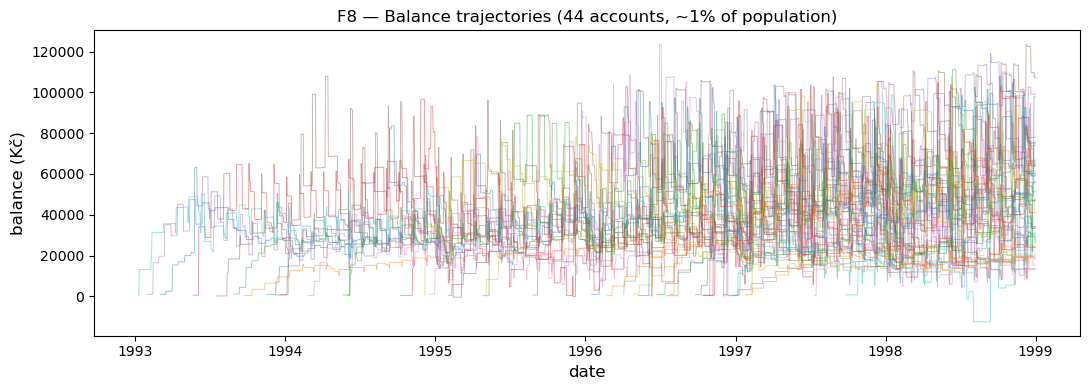

In [10]:
rng = np.random.default_rng(42)
sample = rng.choice(balance_pivot.index, size=max(1, balance_pivot.shape[0] // 100), replace=False)
fig, ax = plt.subplots(figsize=(11, 4))
for acct in sample:
    ax.plot(balance_pivot.columns, balance_pivot.loc[acct].values, lw=0.6, alpha=0.5)
ax.set_xlabel('date'); ax.set_ylabel('balance (Kč)')
ax.set_title(f'F8 — Balance trajectories ({len(sample)} accounts, ~1% of population)')
fig.tight_layout()


## 2. Inputs — what the simulator needs

Each subsection below characterizes one ingredient and reports the calibration number(s) needed for the simulator. Entire section is empirical.

### 2.1 $h(s)$ — distribution of spending rates

The paper's $h(s)$ enters the SM integrals (Eqs. 18–29) as $h(s) \sim s^\sigma$ on $[s_{\min}, s_{\max}]$. Two parametric simulator-feed options:

**(A) Uniform $\sigma=0$ fit** on $[s_{\min}, s_{\max}]$ (1st/99th percentiles to be robust to tail outliers). Matches the analytical-tractable case used throughout the SM, but visually too flat compared to the empirical hump.

**(B) Log-normal** parametric fit: $\log s \sim \mathcal{N}(\mu, \sigma^2)$, MLE on $\log s$. Captures the right-skewed shape with two parameters; the natural physics-paper choice for an $h(s)$ that isn't quite a power-law and isn't quite uniform.

all debits   n=4,427  mean=0.105  median=0.096  [min=0.0169, max=0.3076]  [p01=0.0294, p99=0.2404]
             log-normal: mu=-2.359  sigma=0.479
voluntary    n=4,427  mean=0.142  median=0.128  [min=0.0199, max=0.4800]  [p01=0.0367, p99=0.3367]
             log-normal: mu=-2.065  sigma=0.486


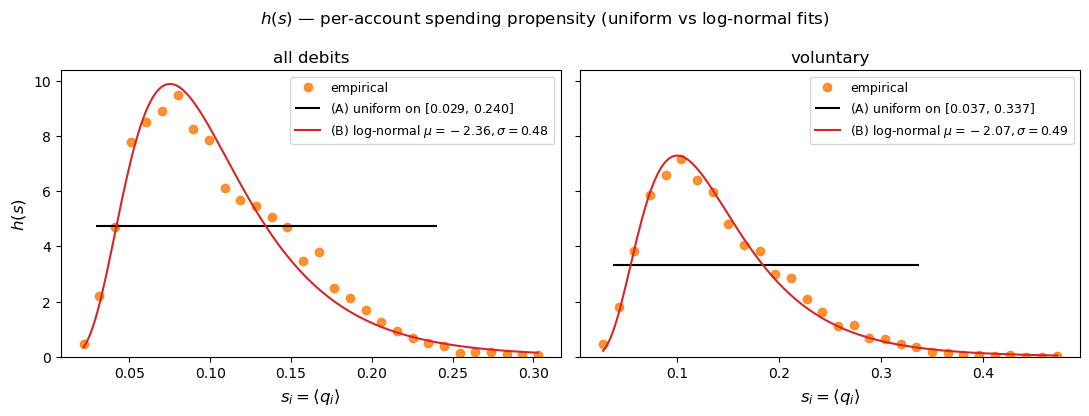

In [11]:
def hs_summary(values, name):
    v = np.asarray(values.dropna())
    p01, p99 = np.quantile(v, [0.01, 0.99])
    log_v = np.log(v[v > 0])
    return {
        'name': name,
        'n': len(v),
        's_mean': float(v.mean()),
        's_median': float(np.median(v)),
        's_min': float(v.min()),
        's_max': float(v.max()),
        's_min_p01': float(p01),
        's_max_p99': float(p99),
        'mu_log':    float(log_v.mean()),
        'sigma_log': float(log_v.std(ddof=1)),
    }

hs_all = hs_summary(agents['mean_frac_out_all'],       'all debits')
hs_vol = hs_summary(agents['mean_frac_out_voluntary'], 'voluntary')

for h in (hs_all, hs_vol):
    print(f"{h['name']:11s}  n={h['n']:,}  mean={h['s_mean']:.3f}  median={h['s_median']:.3f}  "
          f"[min={h['s_min']:.4f}, max={h['s_max']:.4f}]  [p01={h['s_min_p01']:.4f}, p99={h['s_max_p99']:.4f}]")
    print(f"             log-normal: mu={h['mu_log']:.3f}  sigma={h['sigma_log']:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, h, col in zip(axes, [hs_all, hs_vol], ['mean_frac_out_all', 'mean_frac_out_voluntary']):
    vals = agents[col].dropna()
    centers, dens = histogram(vals, num_bins=30, log_bin=False)
    ax.plot(centers, dens, marker='o', linestyle='', alpha=0.85, color='C1', label='empirical')

    # (A) uniform on [p01, p99]
    s_lo, s_hi = h['s_min_p01'], h['s_max_p99']
    ax.hlines(1.0 / (s_hi - s_lo), s_lo, s_hi, color='k', lw=1.5,
              label=fr'(A) uniform on $[{s_lo:.3f},\,{s_hi:.3f}]$')

    # (B) log-normal parametric fit
    xs_ln = np.linspace(centers.min(), centers.max(), 200)
    pdf_ln = _lognorm_dist.pdf(xs_ln, s=h['sigma_log'], scale=np.exp(h['mu_log']))
    ax.plot(xs_ln, pdf_ln, color='C3', lw=1.5,
            label=fr"(B) log-normal $\mu={h['mu_log']:.2f}, \sigma={h['sigma_log']:.2f}$")

    ax.set_xlabel(r'$s_i = \langle q_i \rangle$')
    ax.set_title(h['name'])
    ax.set_ylim(bottom=0)
    ax.legend(loc='upper right', fontsize=9)
axes[0].set_ylabel(r'$h(s)$')
fig.suptitle(r'$h(s)$ — per-account spending propensity (uniform vs log-normal fits)')
fig.tight_layout()


### 2.2 Within-account dispersion $\hat\xi$

The Beta-Binomial precision parameter from the paper's model: under $w \sim \mathrm{BetaBin}(M, \xi s, \xi(1-s))$, the per-tx fraction $q = w/M$ has $\mathrm{Var}(q\mid i) \approx s_i(1-s_i)/(\xi+1)$ (large-$M$ limit). So $\xi$ is calibrated by the slope of empirical per-account $\mathrm{Var}(q\mid i)$ against $s_i(1-s_i)$.

Two views:

1. **Within-account residuals** $r_{ij} = q_{ij} - \langle q_i \rangle$, with the variance decomposition $\mathrm{Var}(q) = \mathrm{Var}(\langle q_i \rangle) + \mathbb{E}[\mathrm{Var}(q\mid i)]$ split into between- vs within-account contributions.
2. **Direct $\hat\xi$** by moment-matching $\hat\xi = \mathbb{E}_i[s_i(1-s_i)] / \mathbb{E}_i[\mathrm{Var}(q\mid i)] - 1$, with the per-account scatter overlaid by the implied $1/(\hat\xi+1)$ slope-1 line. Paper's Sarafu calibration $\xi=1$ shown for reference.

all debits: Var(q)=0.0143  ->  between=0.0021 (14%)  within=0.0131 (86%)
voluntary : Var(q)=0.0146  ->  between=0.0039 (26%)  within=0.0114 (74%)


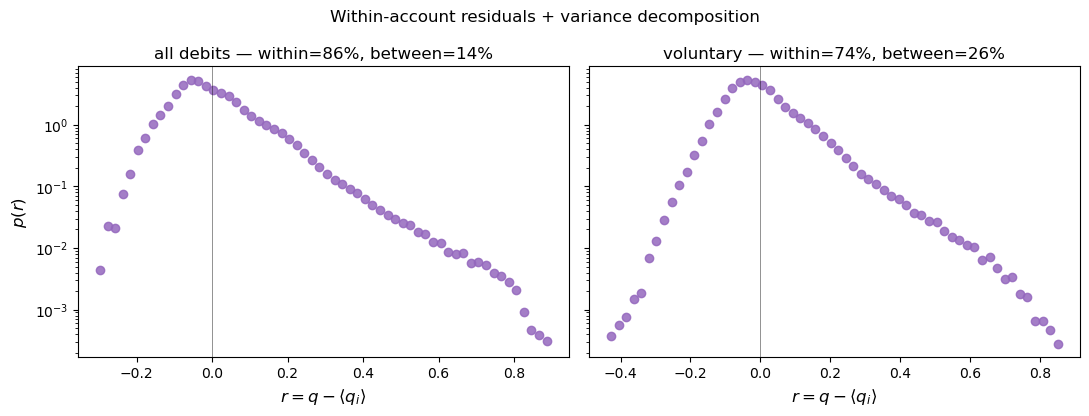

In [12]:
def residuals_and_decomp(q_series, account_ids):
    mask = q_series.notna()
    q = q_series[mask]; a = account_ids[mask]
    mean_per = q.groupby(a, observed=True).transform('mean')
    r = (q - mean_per).rename('r')
    return r, mean_per.var(), q.groupby(a, observed=True).var().mean()

q_all = tx['frac_out']
q_vol = tx['frac_out'].where(tx['voluntary'])
r_all, b_all, w_all = residuals_and_decomp(q_all, tx['account_id'])
r_vol, b_vol, w_vol = residuals_and_decomp(q_vol, tx['account_id'])
print(f"all debits: Var(q)={q_all.var():.4f}  ->  between={b_all:.4f} ({b_all/(b_all+w_all):.0%})  within={w_all:.4f} ({w_all/(b_all+w_all):.0%})")
print(f"voluntary : Var(q)={q_vol.var():.4f}  ->  between={b_vol:.4f} ({b_vol/(b_vol+w_vol):.0%})  within={w_vol:.4f} ({w_vol/(b_vol+w_vol):.0%})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, (label, r, b, w) in zip(axes, [('all debits', r_all, b_all, w_all), ('voluntary', r_vol, b_vol, w_vol)]):
    centers, dens = histogram(r, num_bins=60, log_bin=False)
    ax.plot(centers, dens, marker='o', linestyle='', alpha=0.85, color='C4')
    ax.axvline(0, color='k', lw=0.6, alpha=0.5)
    frac_within = w / (b + w)
    ax.set_xlabel(r'$r = q - \langle q_i \rangle$')
    ax.set_title(f'{label} — within={frac_within:.0%}, between={1-frac_within:.0%}')
    ax.set_yscale('log')
axes[0].set_ylabel(r'$p(r)$')
fig.suptitle('Within-account residuals + variance decomposition')
fig.tight_layout()


xi_hat (all debits) = 6.20   (4,389 accounts with n>=20)
xi_hat (voluntary)  = 9.26   (4,335 accounts with n>=20)
(Sarafu calibration in paper: xi=1)


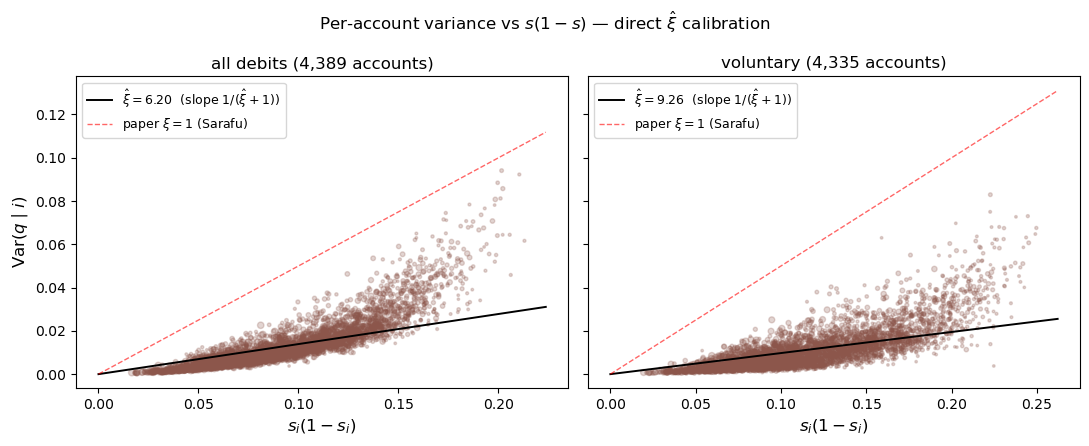

In [13]:
def per_account_moments(q_series, account_ids, min_n=20):
    mask = q_series.notna()
    g = q_series[mask].groupby(account_ids[mask], observed=True)
    df = pd.DataFrame({'s': g.mean(), 'var': g.var(ddof=1), 'n': g.size()})
    return df[df['n'] >= min_n]

def estimate_xi(per_acct):
    w = per_acct['n']
    e_s1ms = np.average(per_acct['s'] * (1 - per_acct['s']), weights=w)
    e_var  = np.average(per_acct['var'],                     weights=w)
    return float(e_s1ms / e_var - 1), float(e_s1ms), float(e_var)

pa_all = per_account_moments(q_all, tx['account_id'])
pa_vol = per_account_moments(q_vol, tx['account_id'])
xi_all, _, _ = estimate_xi(pa_all)
xi_vol, _, _ = estimate_xi(pa_vol)
print(f'xi_hat (all debits) = {xi_all:.2f}   ({len(pa_all):,} accounts with n>=20)')
print(f'xi_hat (voluntary)  = {xi_vol:.2f}   ({len(pa_vol):,} accounts with n>=20)')
print(f'(Sarafu calibration in paper: xi=1)')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, (label, pa, xi_hat) in zip(axes, [('all debits', pa_all, xi_all), ('voluntary', pa_vol, xi_vol)]):
    x = (pa['s'] * (1 - pa['s'])).values
    y = pa['var'].values
    ax.scatter(x, y, s=2 + 0.05*pa['n'].values, alpha=0.25, color='C5')
    xs = np.linspace(0, x.max() * 1.05, 50)
    ax.plot(xs, xs / (xi_hat + 1), 'k-', lw=1.4, label=fr'$\hat\xi={xi_hat:.2f}$  (slope $1/(\hat\xi+1)$)')
    ax.plot(xs, xs / 2,            'r--', lw=1, alpha=0.6, label=r'paper $\xi=1$ (Sarafu)')
    ax.set_xlabel(r'$s_i(1-s_i)$')
    ax.set_title(f'{label} ({len(pa):,} accounts)')
    ax.legend(loc='upper left', fontsize=9)
axes[0].set_ylabel(r'$\mathrm{Var}(q\mid i)$')
fig.suptitle(r'Per-account variance vs $s(1-s)$ — direct $\hat\xi$ calibration')
fig.tight_layout()


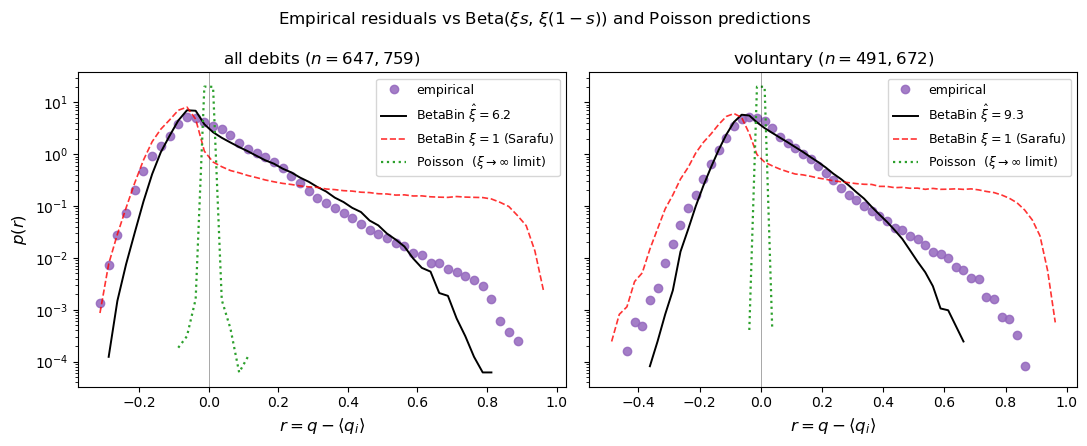

In [14]:
# F2d-style: empirical residuals overlaid with BetaBin and Poisson predictions.
def simulate_residuals_beta(account_ids, s_per_account, xi, seed=42):
    s = account_ids.map(s_per_account).to_numpy()
    s = np.clip(s, 1e-4, 1 - 1e-4)
    rng = np.random.default_rng(seed)
    q = rng.beta(xi * s, xi * (1 - s))
    return q - s

def simulate_residuals_poisson(account_ids, s_per_account, m_per_tx, seed=44):
    s = account_ids.map(s_per_account).to_numpy()
    rng = np.random.default_rng(seed)
    lam = np.clip(m_per_tx * s, 0, None)
    w = rng.poisson(lam)
    return w / m_per_tx - s

cases = [
    ('all debits', q_all, agents['mean_frac_out_all'],       xi_all),
    ('voluntary',  q_vol, agents['mean_frac_out_voluntary'], xi_vol),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, (label, q_series, s_series, xi_hat) in zip(axes, cases):
    mask = q_series.notna() & tx['account_id'].map(s_series).notna() & (tx['pre_balance'] > 0)
    aids = tx.loc[mask, 'account_id']
    m_t  = tx.loc[mask, 'pre_balance'].to_numpy()

    r_emp     = (q_series.loc[mask] - aids.map(s_series)).to_numpy()
    r_xihat   = simulate_residuals_beta(aids, s_series, xi_hat)
    r_xi1     = simulate_residuals_beta(aids, s_series, 1.0, seed=43)
    r_poisson = simulate_residuals_poisson(aids, s_series, m_t)

    edges = np.linspace(-1, 1, 81)
    centers = 0.5 * (edges[:-1] + edges[1:])
    for r, lbl, kw in [
        (r_emp,     'empirical',                          dict(marker='o', linestyle='', color='C4', alpha=0.85)),
        (r_xihat,   fr'BetaBin $\hat\xi={xi_hat:.1f}$',   dict(linestyle='-',  color='k',     lw=1.4)),
        (r_xi1,     r'BetaBin $\xi=1$ (Sarafu)',          dict(linestyle='--', color='r',     lw=1.2, alpha=0.8)),
        (r_poisson, r'Poisson  ($\xi\to\infty$ limit)',   dict(linestyle=':',  color='C2',    lw=1.6)),
    ]:
        d, _ = np.histogram(r, bins=edges, density=True)
        d = np.where(d > 0, d, np.nan)
        ax.plot(centers, d, label=lbl, **kw)
    ax.axvline(0, color='k', lw=0.6, alpha=0.4)
    ax.set_xlabel(r'$r = q - \langle q_i \rangle$')
    ax.set_yscale('log')
    ax.set_title(f'{label} ($n={mask.sum():,}$)')
    ax.legend(loc='upper right', fontsize=9)
axes[0].set_ylabel(r'$p(r)$')
fig.suptitle(r'Empirical residuals vs Beta($\xi s$, $\xi(1-s)$) and Poisson predictions')
fig.tight_layout()

### 2.3 Activity & attractiveness — degree distributions

Per-account in- and out-degree: how many transactions each account sends ($\mathrm{tx}_\mathrm{out}$) and receives ($\mathrm{tx}_\mathrm{in}$) over the 6-year window. These are the marginals of the joint $(a, b)$ distribution that drives the simulator's `activate` and `select` modules.

Two panels, each overlaying both directions:
- **all transactions** (left) — every CREDIT and every DEBIT, including Fees.
- **voluntary** (right) — non-Fee only (drops monthly interest credits and bank service charges).

Log-normal fits on each marginal ($\log n \sim \mathcal{N}(\mu, \sigma^2)$). Per-day rates for the simulator: $\mathrm{LogNormal}(\mu - \log T, \sigma)$ with $T = 2{,}191$ days.

Log-normal fits (6-yr counts):
  all transactions   out:  mu=4.796  sigma=0.663  mean=146.9  median=129.0  (n=4,427)
  all transactions   in :  mu=4.387  sigma=0.518  mean=91.1  median=82.0  (n=4,427)
  voluntary          out:  mu=4.499  sigma=0.686  mean=111.3  median=95.0  (n=4,427)
  voluntary          in :  mu=3.774  sigma=0.533  mean=49.9  median=45.0  (n=4,427)


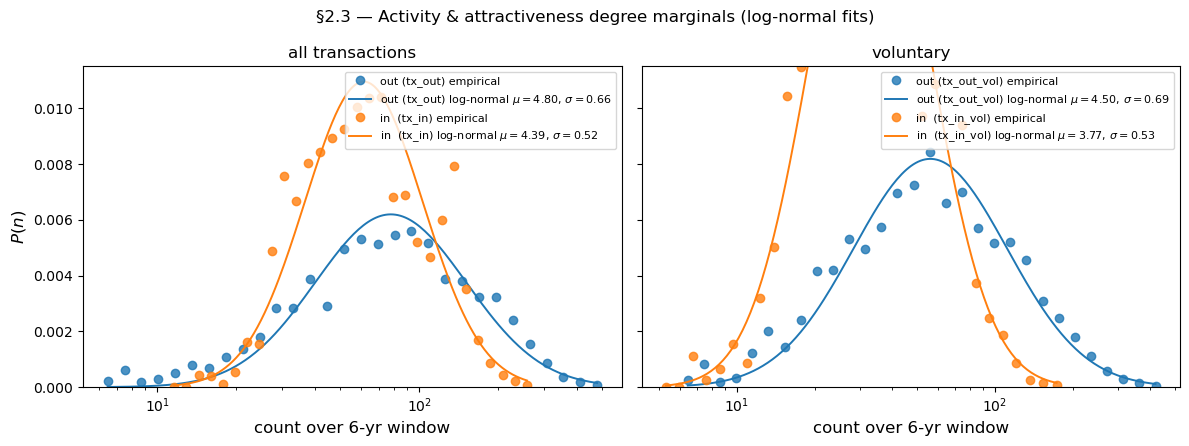

In [15]:
def fit_lognormal(vals):
    v = np.asarray(vals)
    v = v[(v > 0) & np.isfinite(v)]
    log_v = np.log(v)
    return {
        'mu': float(log_v.mean()), 'sigma': float(log_v.std(ddof=1)),
        'mean': float(v.mean()),   'median': float(np.median(v)),
        'n': int(len(v)),
    }

def plot_marginal(ax, vals, color, label_prefix):
    vals = np.asarray(vals)
    vals = vals[(vals > 0) & np.isfinite(vals)]
    centers, dens = histogram(vals, num_bins=30, log_bin=True)
    ax.plot(centers, dens, marker='o', linestyle='', color=color, alpha=0.8, label=f'{label_prefix} empirical')
    f = fit_lognormal(vals)
    xs = np.geomspace(centers.min(), centers.max(), 200)
    pdf = _lognorm_dist.pdf(xs, s=f['sigma'], scale=np.exp(f['mu']))
    ax.plot(xs, pdf, color=color, lw=1.4, ls='-',
            label=fr"{label_prefix} log-normal $\mu={f['mu']:.2f},\,\sigma={f['sigma']:.2f}$")
    return f

deg_fits = {}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
panels = [
    ('all transactions', 'tx_out', 'tx_in'),
    ('voluntary',         'tx_out_vol', 'tx_in_vol'),
]
for ax, (title, out_col, in_col) in zip(axes, panels):
    deg_fits[(title, 'out')] = plot_marginal(ax, agents[out_col], 'C0', f'out ({out_col})')
    deg_fits[(title, 'in')]  = plot_marginal(ax, agents[in_col],  'C1', f'in  ({in_col})')
    ax.set_xscale('log')
    ax.set_xlabel('count over 6-yr window')
    ax.set_title(title)
    ax.set_ylim(bottom=0)
    ax.legend(loc='upper right', fontsize=8)
axes[0].set_ylabel(r'$P(n)$')
fig.suptitle('§2.3 — Activity & attractiveness degree marginals (log-normal fits)')
fig.tight_layout()

print('Log-normal fits (6-yr counts):')
for (panel, side), f in deg_fits.items():
    print(f"  {panel:18s} {side:3s}:  mu={f['mu']:.3f}  sigma={f['sigma']:.3f}  "
          f"mean={f['mean']:.1f}  median={f['median']:.1f}  (n={f['n']:,})")


### 2.4 Joint dependence of $(\mathrm{tx}_\mathrm{in}, \mathrm{tx}_\mathrm{out})$ — copula structure

The simulator's `select` module needs to know how a node's incoming activity correlates with its outgoing activity. We fit a copula on the rank-transformed degree pair, picking the Archimedean family with the highest CMLE log-likelihood that's within a 5% margin of the absolute best (parsimony rule — favor classic families like clayton/frank over rotated/2-parameter ones unless they're substantively better).

Two fits, mirroring the degree panels in §2.3:
- **all transactions**: $(\mathrm{tx}_\mathrm{in}, \mathrm{tx}_\mathrm{out})$ over every CREDIT and DEBIT
- **voluntary**: $(\mathrm{tx}_\mathrm{in,vol}, \mathrm{tx}_\mathrm{out,vol})$ over non-Fee transactions

We do **not** fit a copula on $(\mathrm{vol}_\mathrm{in}, \mathrm{vol}_\mathrm{out})$ — those are model *outputs*, downstream of the activity dynamics + the per-tx spending. Their joint structure is a thing for §4.5 to compare against.

 message: Inequality constraints incompatible
 success: False
  status: 4
     fun: nan
       x: [ 1.000e+00  1.000e+00]
     nit: 1
     jac: [       nan        nan]
    nfev: 3
    njev: 1
optimization failed
 message: Inequality constraints incompatible
 success: False
  status: 4
     fun: nan
       x: [ 1.000e+00  1.000e+00]
     nit: 1
     jac: [       nan        nan]
    nfev: 3
    njev: 1
optimization failed
all transactions:  best family = frank   param = [11.35810547]   CMLE = 3164.0
voluntary:  best family = rjoe   param = [2.52128035]   CMLE = 2530.8


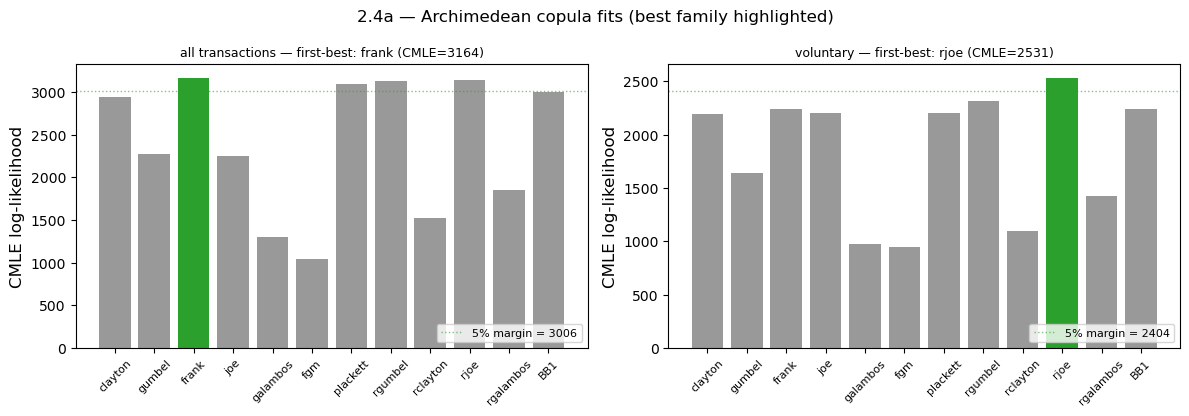

In [16]:
try:
    from pycop import archimedean, estimation
    have_pycop = True
except ImportError:
    have_pycop = False
    print('pycop not available; copula fits skipped.')

copula_results = {}
pairs = {
    'all transactions':  agents[['tx_in',     'tx_out']    ].dropna(),
    'voluntary':         agents[['tx_in_vol', 'tx_out_vol']].dropna(),
}
if have_pycop:
    fig, axes = plt.subplots(1, len(pairs), figsize=(12, 4.2), squeeze=False)
    axes = axes[0]
    for ax, (pair_name, pair_df) in zip(axes, pairs.items()):
        data = pair_df.rank(pct=True).T.values
        types, scores, params = [], [], []
        for fam in archimedean.Archimedean_families:
            try:
                cop = archimedean(fam)
                p, cmle = estimation.fit_cmle(cop, data)
                types.append(fam); scores.append(float(cmle)); params.append(p)
            except Exception:
                pass
        if types:
            # First-best selection: pycop's Archimedean_families is ordered roughly by usualness
            # (clayton, gumbel, frank, joe first; bespoke / 2-parameter / rotated ones later).
            # Pick the leftmost family within FIRST_BEST_MARGIN of the global maximum CMLE,
            # so a simpler family wins unless a more complex one is substantially better.
            FIRST_BEST_MARGIN = 0.05    # 5% of best CMLE
            argmax_idx = int(np.argmax(scores))
            best_cmle_overall = scores[argmax_idx]
            threshold = best_cmle_overall * (1 - FIRST_BEST_MARGIN)
            chosen_idx = next(i for i, c in enumerate(scores) if c >= threshold)
            copula_results[pair_name] = {
                'best_family': types[chosen_idx],
                'best_param':  params[chosen_idx],
                'best_cmle':   scores[chosen_idx],
                'argmax_family': types[argmax_idx],
                'argmax_cmle':   scores[argmax_idx],
                'all':         dict(zip(types, scores)),
            }
            colors = ['C2' if i == chosen_idx else ('C0' if i == argmax_idx else '0.6')
                      for i in range(len(types))]
            ax.bar(types, scores, color=colors)
            ax.axhline(threshold, color='C2', ls=':', lw=1, alpha=0.6,
                       label=f'5% margin = {threshold:.0f}')
            ax.legend(loc='lower right', fontsize=8)
            title = f'{pair_name} — first-best: {types[chosen_idx]} (CMLE={scores[chosen_idx]:.0f})'
            if chosen_idx != argmax_idx:
                title += f"\nargmax was {types[argmax_idx]} (CMLE={scores[argmax_idx]:.0f})"
            ax.set_title(title, fontsize=9)
            ax.tick_params(axis='x', rotation=45, labelsize=8)
            ax.set_ylabel('CMLE log-likelihood')
    fig.suptitle('2.4a — Archimedean copula fits (best family highlighted)')
    fig.tight_layout()
    for name, res in copula_results.items():
        print(f"{name}:  best family = {res['best_family']}   param = {res['best_param']}   CMLE = {res['best_cmle']:.1f}")


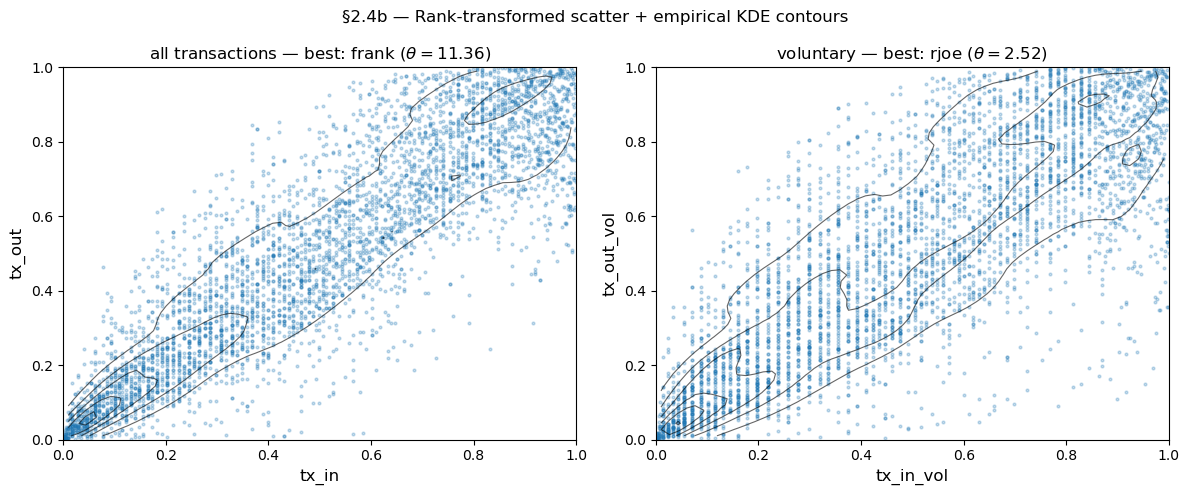

In [17]:
# Empirical rank-transformed scatter with KDE contours.
# (We don't overlay synthetic copula samples because pycop's archimedean class doesn't expose
# a sampler; the fit is summarized by the family + parameter from §2.4a, which is what the
# simulator actually needs.)
from scipy.stats import gaussian_kde

if copula_results:
    fig, axes = plt.subplots(1, len(pairs), figsize=(12, 5), squeeze=False)
    axes = axes[0]
    for ax, (pair_name, df) in zip(axes, pairs.items()):
        u = df.iloc[:, 0].rank(pct=True).to_numpy()
        v = df.iloc[:, 1].rank(pct=True).to_numpy()
        ax.scatter(u, v, s=4, alpha=0.25, color='C0')
        kde = gaussian_kde(np.vstack([u, v]), bw_method=0.15)
        gx = np.linspace(0.01, 0.99, 60)
        GX, GY = np.meshgrid(gx, gx)
        Z = kde(np.vstack([GX.ravel(), GY.ravel()])).reshape(GX.shape)
        ax.contour(GX, GY, Z, levels=6, colors='k', alpha=0.6, linewidths=0.8)

        res = copula_results[pair_name]
        param = res['best_param']
        param_str = f'{param[0]:.2f}' if hasattr(param, '__len__') else f'{param:.2f}'
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_xlabel(df.columns[0])
        ax.set_ylabel(df.columns[1])
        ax.set_title(rf"{pair_name} — best: {res['best_family']} ($\theta={param_str}$)")
    fig.suptitle('§2.4b — Rank-transformed scatter + empirical KDE contours')
    fig.tight_layout()


## 3. Intermediate — conditional $P(m \mid s)$

The SM Fig. `conditional_distributions.pdf` (near Eq. 29) compares simulated $p(m\mid s)$ to a Negative Binomial prediction $\mathrm{NB}(r, r/(r+\lambda_s))$, *one curve per spending rate*. Berka has enough accounts to do the empirical analog: bin accounts by their per-account $s_i$, plot the within-bin balance distribution, all on the same axes with one color per bin.

The NB curves shown here are **moment-matched** to each bin's empirical mean and variance — *not* derived from the SM theory. The full theoretical comparison ($\mathrm{NB}(r_\mathrm{eff}, r_\mathrm{eff}/(r_\mathrm{eff}+\lambda_s))$ with $r_\mathrm{eff}$ from $r$ and $\hat\xi$) is a job for the simulation task; it requires evaluating the SM integrals, which lives in the follow-up notebook.

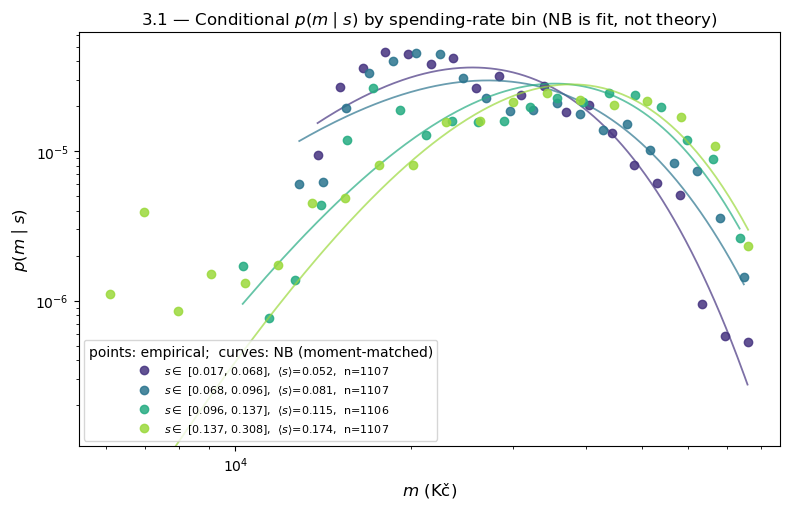

In [18]:
s_acct = agents['mean_frac_out_all']
m_acct = agents['mean_bal']
ok = s_acct.notna() & m_acct.notna() & (m_acct > 0)
s_acct, m_acct = s_acct[ok], m_acct[ok]
n_bins = 4
quantiles = np.linspace(0, 1, n_bins + 1)
edges = s_acct.quantile(quantiles).values
bin_idx = pd.cut(s_acct, edges, include_lowest=True, labels=False).astype('Int64')

fig, ax = plt.subplots(1, 1, figsize=(8, 5.2))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, n_bins))
y_floor = 1e-7
all_dens_min = []
for k in range(n_bins):
    in_bin = bin_idx == k
    s_lo, s_hi = edges[k], edges[k+1]
    s_mean_bin = float(s_acct[in_bin].mean())
    m_vals = m_acct[in_bin].to_numpy()
    n_in = len(m_vals)
    if n_in < 30:
        continue
    centers, dens = histogram(m_vals, num_bins=20, log_bin=True)
    all_dens_min.append(dens[dens > 0].min())
    ax.plot(centers, dens, marker='o', linestyle='', color=colors[k], alpha=0.85,
            label=fr'$s \in$ [{s_lo:.3f}, {s_hi:.3f}],  $\langle s \rangle$={s_mean_bin:.3f},  n={n_in}')
    # NB curve moment-matched to bin's empirical (mean, variance) — fit, not theory.
    lam = float(m_vals.mean())
    var = float(m_vals.var(ddof=1))
    if var > lam:
        r_emp = lam ** 2 / (var - lam)
        p_emp = r_emp / (r_emp + lam)
        xs_nb = np.geomspace(max(1.0, centers.min()), centers.max(), 300)
        nb_pmf = _nbinom_dist.pmf(np.round(xs_nb).astype(int), n=r_emp, p=p_emp)
        nv = nb_pmf > y_floor
        ax.plot(xs_nb[nv], nb_pmf[nv], color=colors[k], ls='-', lw=1.3, alpha=0.7)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_ylim(bottom=max(y_floor, min(all_dens_min) / 5))
ax.set_xlabel(r'$m$ (Kč)')
ax.set_ylabel(r'$p(m \mid s)$')
ax.legend(loc='lower left', fontsize=8, title='points: empirical;  curves: NB (moment-matched)')
ax.set_title(r'3.1 — Conditional $p(m \mid s)$ by spending-rate bin (NB is fit, not theory)')
fig.tight_layout()


### 3.2 Mean balance vs normalized incoming activity

Bin accounts by $\mathrm{tx}_\mathrm{in} / \langle \mathrm{tx}_\mathrm{in} \rangle$ (20 log-spaced bins), report mean balance per bin. Tests whether $\langle m \rangle$ scales with inflow, which it should under any sensible balance-conserving dynamics.

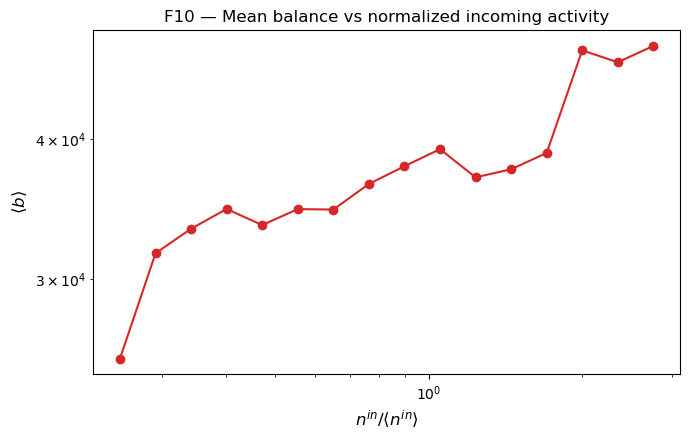

In [19]:
x = agents['tx_in'] / agents['tx_in'].mean()
y = agents['mean_bal']
mask = (x > 0) & y.notna()
x, y = x[mask], y[mask]
edges = np.logspace(np.log10(x.min()), np.log10(x.max()), 21)
centers = np.sqrt(edges[:-1] * edges[1:])
binned = pd.cut(x, edges, include_lowest=True)
binned_mean = y.groupby(binned, observed=True).mean()
binned_count = y.groupby(binned, observed=True).count()
fig, ax = plt.subplots(figsize=(7, 4.5))
valid = binned_count > 5
ax.plot(centers[valid.values], binned_mean[valid.values].values, marker='o', linestyle='-', color='C3')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$n^{in} / \langle n^{in} \rangle$')
ax.set_ylabel(r'$\langle b \rangle$')
ax.set_title('F10 — Mean balance vs normalized incoming activity')
fig.tight_layout()

### 3.3 Is $s$ independent of activity / attractiveness / inflows?

The SM derivations assume $h(s)$ is independent of $P(a, b)$. Berka shows the empirical $\langle m \rangle$ *increases* with $s$ — the opposite of $\lambda_s = K_0/s$. Two possible explanations:

1. **Correlation with activity**: high-$s$ accounts also have high $a$ and/or $b$, so they get more inflows, more balance.
2. **Correlation with deposit size**: high-$s$ accounts receive larger individual deposits (e.g. salary level), so absolute balance is high even though they spend a larger *fraction* per transaction.

Cleanest test: Spearman $\rho$ of $s_i$ against $a_i$ ($\mathrm{tx}_\mathrm{out}$), $b_i$ ($\mathrm{tx}_\mathrm{in}$), mean incoming amount, and mean outgoing amount. The independence assumption requires $|\rho| \approx 0$ for the activity pair; non-zero correlations with the *amount* variables would point to (2) — and to a Berka-vs-Sarafu structural difference, since Berka's external salary inflows aren't part of the closed-system SM model.

Spearman correlations with s = <q_i>:
  a (tx_out)                 rho = -0.112
  b (tx_in)                  rho = -0.068
  mean amount in             rho = +0.725
  mean amount out            rho = +0.845


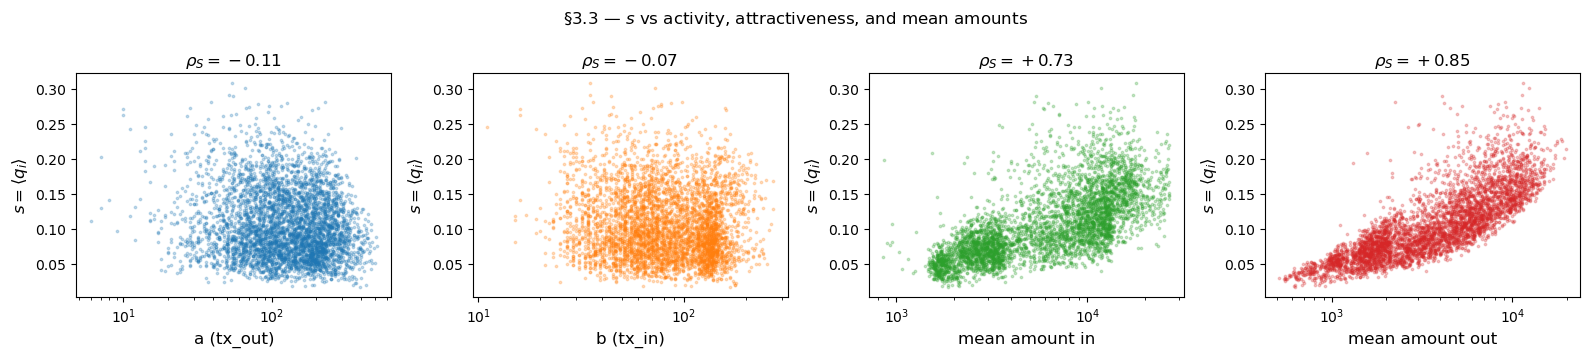

In [20]:
from scipy.stats import spearmanr

s_i = agents['mean_frac_out_all']
a_i = agents['tx_out']
b_i = agents['tx_in']
mean_amt_in  = (tx[tx['type'].eq('CREDIT')].groupby('account_id', observed=True)['amount']
                .mean().reindex(agents.index))
mean_amt_out = (tx[tx['type'].eq('DEBIT' )].groupby('account_id', observed=True)['amount']
                .mean().reindex(agents.index))

specs = [
    ('a (tx_out)',          a_i,            'C0'),
    ('b (tx_in)',           b_i,            'C1'),
    ('mean amount in',      mean_amt_in,    'C2'),
    ('mean amount out',     mean_amt_out,   'C3'),
]
print('Spearman correlations with s = <q_i>:')
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
for ax, (label, vals, color) in zip(axes, specs):
    ok = vals.notna() & s_i.notna()
    rho, _ = spearmanr(vals[ok], s_i[ok])
    print(f'  {label:25s}  rho = {rho:+.3f}')
    ax.scatter(vals[ok], s_i[ok], s=3, alpha=0.25, color=color)
    ax.set_xscale('log')
    ax.set_xlabel(label)
    ax.set_ylabel(r'$s = \langle q_i \rangle$')
    ax.set_title(fr'$\rho_{{S}} = {rho:+.2f}$')
fig.suptitle(r'§3.3 — $s$ vs activity, attractiveness, and mean amounts')
fig.tight_layout()


## 4. Outputs — what the simulator must reproduce

Each of these panels is what the simulator should be compared against. The current notebook plots empirical only, with Poisson as the literature null. The follow-up simulation task should produce simulator curves and overlay them on these panels (no other change required).

### 4.1 $P(m)$, $P(w_\mathrm{in})$, $P(w_\mathrm{out})$ — per-event distributions

Three stylized outputs on shared log-log axes. $P(m)$ is the snapshot balance distribution (last day of observation); $P(w_\mathrm{in})$ and $P(w_\mathrm{out})$ are per-transaction amount distributions for incoming and outgoing transactions respectively.

The SM's closed-system framing implicitly assumes $P(w_\mathrm{in})=P(w_\mathrm{out})$ — every outflow is somebody else's inflow. Berka is open (external salaries etc.), so we expect divergence: in-transactions can be much larger than typical out-transactions.

Two panels:
- **all transactions** — every CREDIT (in) and every DEBIT (out)
- **voluntary** — drops Fee transactions (interest credits and service charges) from both directions

$P(m)$ is the same in both panels (balance doesn't depend on which transactions you select). Each variable has its own Poisson($\langle\cdot\rangle$) reference — the literature null, narrow by construction. The follow-up simulation task will overlay simulator output here.

<m> snapshot = 44,515 Kč
all transactions    <w_out>=4,659 Kč   <w_in>=7,992 Kč   (in/out ratio: 1.72)
voluntary           <w_out>=6,139 Kč   <w_in>=14,479 Kč   (in/out ratio: 2.36)


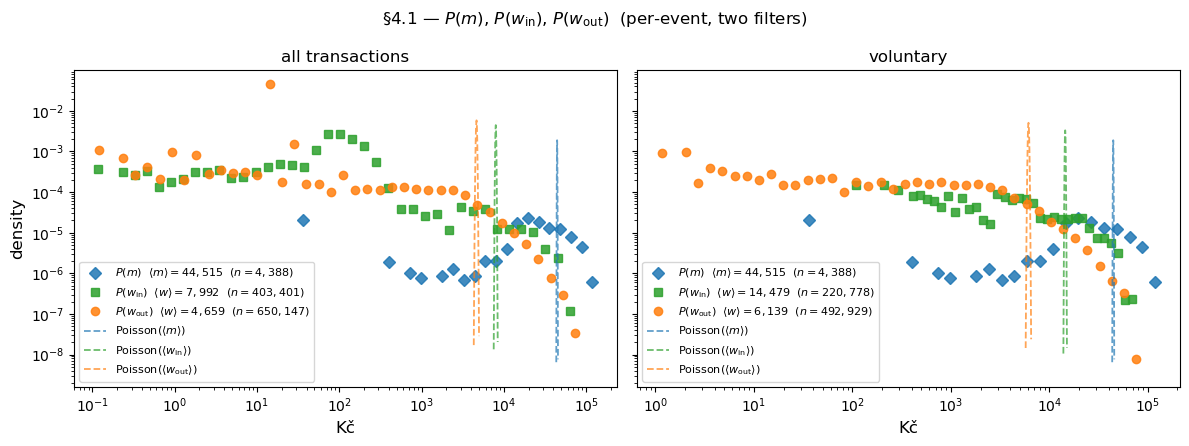

In [21]:
# §4.1 — P(m) and P(w_in) vs P(w_out), two panels (all transactions / voluntary)
def poisson_curve(lam, n=400, span=5.0):
    sig = np.sqrt(lam)
    xs = np.linspace(max(1.0, lam - span*sig), lam + span*sig, n)
    return xs, _poisson_dist.pmf(np.round(xs).astype(int), mu=lam)

# P(m): snapshot balance, last day, one value per account. Same in both panels.
m_vals = balance_pivot.iloc[:, -1].dropna().to_numpy()
m_vals = m_vals[m_vals > 0]
m_mean = float(m_vals.mean())
cm, dm = histogram(m_vals, num_bins=30, log_bin=True)

panels = [
    ('all transactions', tx['type'].eq('DEBIT'), tx['type'].eq('CREDIT')),
    ('voluntary',        tx['type'].eq('DEBIT') & tx['voluntary'],
                          tx['type'].eq('CREDIT') & tx['voluntary']),
]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, (label, mask_out, mask_in) in zip(axes, panels):
    w_out = tx.loc[mask_out, 'amount'].to_numpy()
    w_in  = tx.loc[mask_in,  'amount'].to_numpy()
    w_out, w_in = w_out[w_out > 0], w_in[w_in > 0]
    wm_out, wm_in = float(w_out.mean()), float(w_in.mean())
    co, do = histogram(w_out, num_bins=40, log_bin=True)
    ci, di = histogram(w_in,  num_bins=40, log_bin=True)

    ax.plot(cm[dm>0], dm[dm>0], marker='D', linestyle='', color='C0', alpha=0.85,
            label=fr'$P(m)$  $\langle m \rangle={m_mean:,.0f}$  ($n={len(m_vals):,}$)')
    ax.plot(ci[di>0], di[di>0], marker='s', linestyle='', color='C2', alpha=0.85,
            label=fr'$P(w_\mathrm{{in}})$  $\langle w \rangle={wm_in:,.0f}$  ($n={len(w_in):,}$)')
    ax.plot(co[do>0], do[do>0], marker='o', linestyle='', color='C1', alpha=0.85,
            label=fr'$P(w_\mathrm{{out}})$  $\langle w \rangle={wm_out:,.0f}$  ($n={len(w_out):,}$)')

    xs_m, pm = poisson_curve(m_mean)
    ax.plot(xs_m, pm, color='C0', ls='--', lw=1.3, alpha=0.7, label=r'Poisson($\langle m \rangle$)')
    xs_i, pi = poisson_curve(wm_in)
    ax.plot(xs_i, pi, color='C2', ls='--', lw=1.3, alpha=0.7, label=r'Poisson($\langle w_\mathrm{in} \rangle$)')
    xs_o, po = poisson_curve(wm_out)
    ax.plot(xs_o, po, color='C1', ls='--', lw=1.3, alpha=0.7, label=r'Poisson($\langle w_\mathrm{out} \rangle$)')

    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(r'Kč')
    ax.set_title(label)
    floors = [d[d>0].min() for d in (dm, di, do) if (d > 0).any()]
    ax.set_ylim(bottom=max(1e-9, min(floors) / 5))
    ax.legend(loc='lower left', fontsize=8)
axes[0].set_ylabel('density')
fig.suptitle(r'§4.1 — $P(m)$, $P(w_\mathrm{in})$, $P(w_\mathrm{out})$  (per-event, two filters)')
fig.tight_layout()

print(f'<m> snapshot = {m_mean:,.0f} Kč')
for label, mask_out, mask_in in panels:
    print(f'{label:18s}  <w_out>={tx.loc[mask_out, "amount"].mean():,.0f} Kč   '
          f'<w_in>={tx.loc[mask_in, "amount"].mean():,.0f} Kč   '
          f'(in/out ratio: {tx.loc[mask_in, "amount"].mean()/tx.loc[mask_out, "amount"].mean():.2f})')


### 4.2 $P(\langle m \rangle)$, $P(\langle w_\mathrm{in} \rangle)$, $P(\langle w_\mathrm{out} \rangle)$ — per-account averages

Per-account averages of the §4.1 quantities, plus $\langle m \rangle$. For each account: temporal-mean balance, mean incoming amount, mean outgoing amount. Two panels (all transactions / voluntary). $\langle m \rangle$ doesn't depend on the in/out filter, so the blue squares are identical between panels.

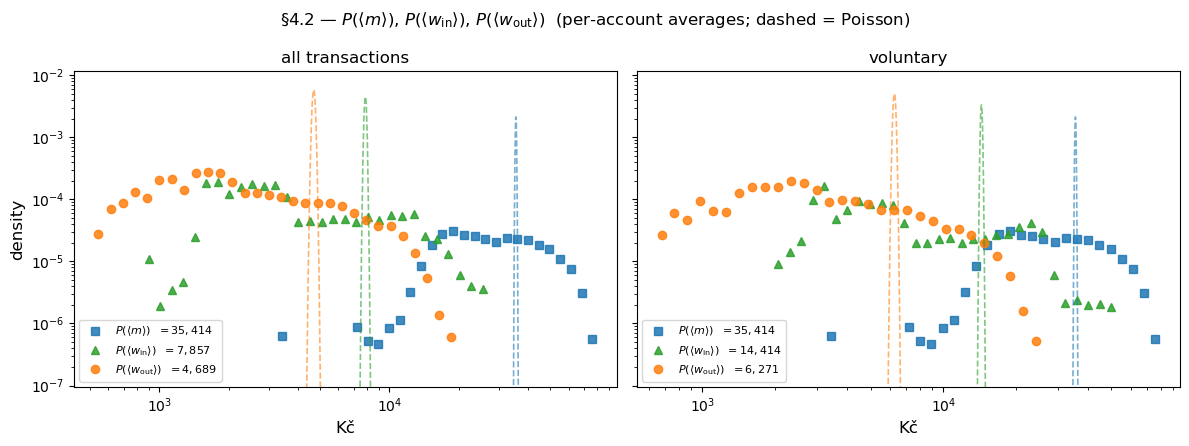

In [22]:
# §4.2 — Per-account averages: P(<m>), P(<w_in>), P(<w_out>); two panels.
m_avg = balance_pivot.mean(axis=1).dropna().to_numpy()
m_avg = m_avg[m_avg > 0]
mavg_mean = float(m_avg.mean())
cma, dma = histogram(m_avg, num_bins=30, log_bin=True)

panels = [
    ('all transactions', tx['type'].eq('DEBIT'), tx['type'].eq('CREDIT')),
    ('voluntary',        tx['type'].eq('DEBIT') & tx['voluntary'],
                          tx['type'].eq('CREDIT') & tx['voluntary']),
]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, (label, mask_out, mask_in) in zip(axes, panels):
    w_out_per = (tx.loc[mask_out].groupby('account_id', observed=True)['amount']
                 .mean().dropna().to_numpy())
    w_in_per  = (tx.loc[mask_in].groupby('account_id', observed=True)['amount']
                 .mean().dropna().to_numpy())
    w_out_per = w_out_per[w_out_per > 0]
    w_in_per  = w_in_per[w_in_per > 0]
    co, do = histogram(w_out_per, num_bins=30, log_bin=True)
    ci, di = histogram(w_in_per,  num_bins=30, log_bin=True)
    wo_mean, wi_mean = float(w_out_per.mean()), float(w_in_per.mean())

    ax.plot(cma[dma>0], dma[dma>0], marker='s', linestyle='', color='C0', alpha=0.85,
            label=fr'$P(\langle m \rangle)$  $={mavg_mean:,.0f}$')
    ax.plot(ci[di>0], di[di>0], marker='^', linestyle='', color='C2', alpha=0.85,
            label=fr'$P(\langle w_\mathrm{{in}} \rangle)$  $={wi_mean:,.0f}$')
    ax.plot(co[do>0], do[do>0], marker='o', linestyle='', color='C1', alpha=0.85,
            label=fr'$P(\langle w_\mathrm{{out}} \rangle)$  $={wo_mean:,.0f}$')

    xs_m, pm = poisson_curve(mavg_mean)
    ax.plot(xs_m, pm, color='C0', ls='--', lw=1.2, alpha=0.6)
    xs_i, pi = poisson_curve(wi_mean)
    ax.plot(xs_i, pi, color='C2', ls='--', lw=1.2, alpha=0.6)
    xs_o, po = poisson_curve(wo_mean)
    ax.plot(xs_o, po, color='C1', ls='--', lw=1.2, alpha=0.6)

    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Kč')
    ax.set_title(label)
    floors = [d[d>0].min() for d in (dma, di, do) if (d > 0).any()]
    ax.set_ylim(bottom=max(1e-9, min(floors) / 5))
    ax.legend(loc='lower left', fontsize=8)
axes[0].set_ylabel('density')
fig.suptitle(r'§4.2 — $P(\langle m \rangle)$, $P(\langle w_\mathrm{in} \rangle)$, $P(\langle w_\mathrm{out} \rangle)$  (per-account averages; dashed = Poisson)')
fig.tight_layout()


### 4.3 Stationarity check — end-of-year $P(m)$

One snapshot $P(m)$ per year-end (1993-12-31 through 1998-12-31), all on the same axes. If Berka's balance distribution is approximately stationary, the six curves overlap. Visible drift would indicate the simulator should target a *time-varying* $P(m)$ rather than a single equilibrium.

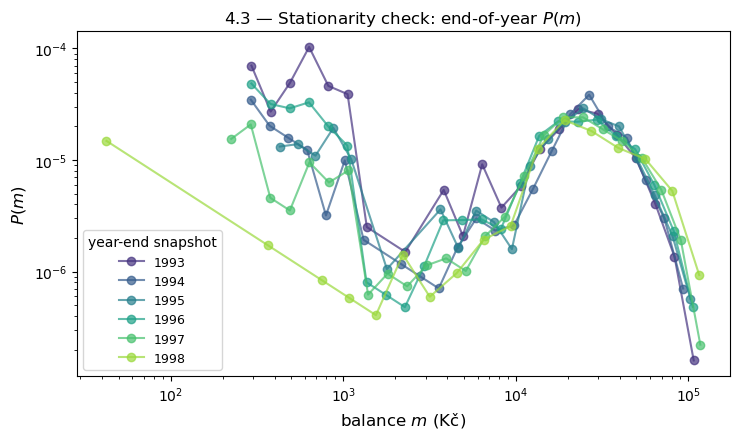

In [23]:
# Stationarity: end-of-year P(m), one curve per year overlaid.
year_ends = [pd.Timestamp(f'{y}-12-31') for y in range(1993, 1999)]
fig, ax = plt.subplots(figsize=(7.5, 4.5))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(year_ends)))
for date, color in zip(year_ends, colors):
    if date not in balance_pivot.columns:
        continue
    bal = balance_pivot[date].dropna().to_numpy()
    bal = bal[bal > 0]
    if len(bal) < 30:
        continue
    c, d = histogram(bal, num_bins=25, log_bin=True)
    keep = d > 0
    ax.plot(c[keep], d[keep], marker='o', linestyle='-', alpha=0.7, color=color,
            label=str(date.year))
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'balance $m$ (Kč)')
ax.set_ylabel(r'$P(m)$')
ax.legend(title='year-end snapshot', loc='lower left', fontsize=9)
ax.set_title('4.3 — Stationarity check: end-of-year $P(m)$')
fig.tight_layout()


### 4.4 $(\mathrm{tx}_\mathrm{in}, \mathrm{tx}_\mathrm{out})$ joint scatter — output

Per-account in- vs. out-**degree**. The same data whose marginals appeared in §2.3 (as inputs to the simulator) now displayed as the joint pattern that the simulator's output should reproduce.

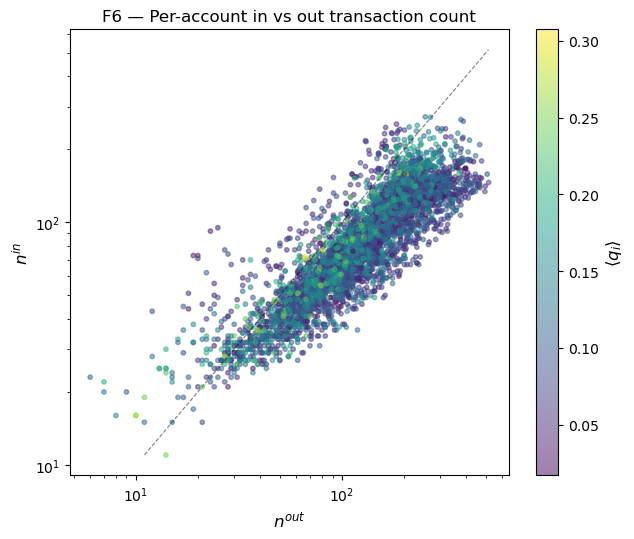

In [24]:
a = agents[(agents['tx_in'] > 0) & (agents['tx_out'] > 0)].copy()
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sc = ax.scatter(a['tx_out'], a['tx_in'],
                c=a['mean_frac_out_all'].fillna(a['mean_frac_out_all'].median()),
                s=10, cmap='viridis', alpha=0.5)
lo = max(a['tx_out'].min(), a['tx_in'].min())
hi = max(a['tx_out'].max(), a['tx_in'].max())
ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, alpha=0.5)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$n^{out}$'); ax.set_ylabel(r'$n^{in}$')
ax.set_title('F6 — Per-account in vs out transaction count')
plt.colorbar(sc, ax=ax, label=r'$\langle q_i \rangle$')
fig.tight_layout()

### 4.5 $(\mathrm{vol}_\mathrm{in}, \mathrm{vol}_\mathrm{out})$ joint scatter

Per-account in vs. out **strength**. Coloring by $\langle q_i \rangle$ shows that the spending-fraction structure inferred from §2.2 also organizes the strength scatter. The simulator should reproduce both the marginal distributions of $\mathrm{vol}_\mathrm{in}$, $\mathrm{vol}_\mathrm{out}$ and their joint structure (the latter via the copula calibration in §2.4).

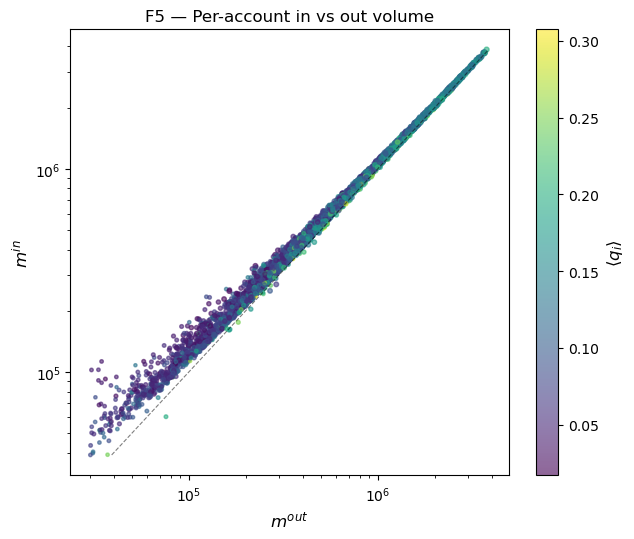

In [25]:
a = agents[(agents['vol_in'] > 0) & (agents['vol_out'] > 0)].copy()
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sc = ax.scatter(a['vol_out'], a['vol_in'],
                c=a['mean_frac_out_all'].fillna(a['mean_frac_out_all'].median()),
                s=4 + 0.5 * np.sqrt(a['tx_out'].clip(lower=1)),
                cmap='viridis', alpha=0.6)
lo = max(a['vol_out'].min(), a['vol_in'].min())
hi = max(a['vol_out'].max(), a['vol_in'].max())
ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, alpha=0.5)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$m^{out}$'); ax.set_ylabel(r'$m^{in}$')
ax.set_title('F5 — Per-account in vs out volume')
plt.colorbar(sc, ax=ax, label=r'$\langle q_i \rangle$')
fig.tight_layout()

### 4.6 Diagnostic: per-transaction $q = w/m$ distribution

Closes the loop on the inputs → outputs flow. The simulator's $\xi$ governs how broad this distribution is for each account; aggregating over accounts gives the population $p(q)$ shown here. Under the Poisson null this would be approximately a delta at each account's $s_i$ — i.e., $p(q) \approx h(s)$ — so the empirical broadening *beyond* $h(s)$ is what $\xi$ controls.

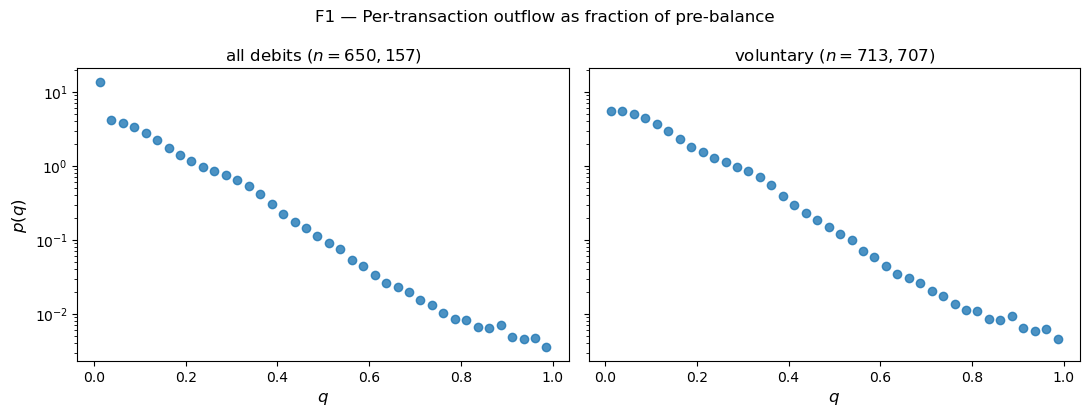

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, (label, mask) in zip(axes, [
    ('all debits', tx['type'].eq('DEBIT')),
    ('voluntary',  tx['voluntary']),
]):
    centers, dens = histogram(tx.loc[mask, 'frac_out'], num_bins=40, log_bin=False)
    ax.plot(centers, dens, marker='o', linestyle='', alpha=0.8, color='C0')
    ax.set_xlabel(r'$q$')
    ax.set_title(f'{label} ($n={mask.sum():,}$)')
    ax.set_yscale('log')
axes[0].set_ylabel(r'$p(q)$')
fig.suptitle('F1 — Per-transaction outflow as fraction of pre-balance')
fig.tight_layout()

## 5. Calibration summary

Single-cell printout of the numbers a simulation task should consume. The simulator code is in `src/`; the corresponding follow-up task should construct a run, produce $P(m)$, $P(w)$, and the joint scatters, and overlay them on the §4 output panels above.

In [27]:
# --- Aggregate observables ---
N_accounts        = int(agents.shape[0])
total_balance_Kc  = float(balance_pivot.sum(axis=0).mean())   # daily-mean total balance
mean_tx_per_acct  = float(agents['tx_out'].mean())
days_obs          = int(balance_pivot.shape[1])
mean_amount_Kc    = float(tx['amount'].mean())

print('=' * 78)
print('BERKA — simulator calibration summary')
print('=' * 78)
print('Population & system size')
print(f'  N (accounts)                          : {N_accounts:,}')
print(f'  Observation window                    : {days_obs:,} days ({days_obs/365.25:.2f} yr)')
print(f'  Total balance in system (daily mean)  : {total_balance_Kc:,.0f} Kč')
print(f'  Mean per-tx amount <w>                : {mean_amount_Kc:,.0f} Kč')
print(f"  Mean per-account balance <m>          : {agents['mean_bal'].mean():,.0f} Kč")
print()
print('Activity & flow')
print(f"  Mean DEBITs per account               : {mean_tx_per_acct:.1f}")
print(f"  Total DEBITs                          : {int(agents['tx_out'].sum()):,}")
print(f"  Total DEBIT volume                    : {agents['vol_out'].sum():,.0f} Kč")
print()
print('Spending propensity h(s) — three options')
print(f"  uniform [s_min, s_max]:")
print(f"    all debits      : [{hs_all['s_min_p01']:.4f}, {hs_all['s_max_p99']:.4f}]   mean={hs_all['s_mean']:.3f}")
print(f"    voluntary       : [{hs_vol['s_min_p01']:.4f}, {hs_vol['s_max_p99']:.4f}]   mean={hs_vol['s_mean']:.3f}")
print(f"  log-normal (mu, sigma):")
print(f"    all debits      : ({hs_all['mu_log']:.3f}, {hs_all['sigma_log']:.3f})")
print(f"    voluntary       : ({hs_vol['mu_log']:.3f}, {hs_vol['sigma_log']:.3f})")
print()
print('Beta-Binomial precision xi (variance moment-match)')
print(f'  all debits      : xi_hat = {xi_all:.2f}   ({len(pa_all):,} accounts with n>=20)')
print(f'  voluntary       : xi_hat = {xi_vol:.2f}   ({len(pa_vol):,} accounts with n>=20)')
print('  (Sarafu calibration in paper: xi=1)')
print()
print('Degree marginals (log-normal fit on the 6-yr counts)')
T_days = days_obs
for (panel, side), d in deg_fits.items():
    mu_rate = d['mu'] - np.log(T_days)
    print(f"  {panel:18s} {side:3s}: mu_count={d['mu']:.3f}, sigma={d['sigma']:.3f}   "
          f"per-day rate: LogNormal(mu={mu_rate:.3f}, sigma={d['sigma']:.3f})")
print()
print('Joint dependence (first-best Archimedean copula, 5% margin)')
if copula_results:
    for name, res in copula_results.items():
        param = res['best_param']
        param_str = f'{param:.3f}' if isinstance(param, (int, float, np.floating)) else str(param)
        print(f"  {name:24s}{res['best_family']:>10s}  param={param_str}  CMLE={res['best_cmle']:.1f}")
else:
    print('  (pycop unavailable — see §2.4 for fitting)')
print('=' * 78)


BERKA — simulator calibration summary
Population & system size
  N (accounts)                          : 4,427
  Observation window                    : 2,191 days (6.00 yr)
  Total balance in system (daily mean)  : 90,806,052 Kč
  Mean per-tx amount <w>                : 5,935 Kč
  Mean per-account balance <m>          : 36,905 Kč

Activity & flow
  Mean DEBITs per account               : 146.9
  Total DEBITs                          : 650,157
  Total DEBIT volume                    : 3,028,915,961 Kč

Spending propensity h(s) — three options
  uniform [s_min, s_max]:
    all debits      : [0.0294, 0.2404]   mean=0.105
    voluntary       : [0.0367, 0.3367]   mean=0.142
  log-normal (mu, sigma):
    all debits      : (-2.359, 0.479)
    voluntary       : (-2.065, 0.486)

Beta-Binomial precision xi (variance moment-match)
  all debits      : xi_hat = 6.20   (4,389 accounts with n>=20)
  voluntary       : xi_hat = 9.26   (4,335 accounts with n>=20)
  (Sarafu calibration in paper: xi=1)

